In [16]:
import json
import re
import sqlite3
import pandas as pd
from pathlib import Path

RAW_FILE = Path("data/raw/recalls_2014_2024.json")
PROCESSED_DIR = Path("data/processed")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

DB_PATH = PROCESSED_DIR / "recalls.db"

# Load JSON
with RAW_FILE.open() as f:
    raw_data = json.load(f)

len(raw_data)

df = pd.DataFrame(raw_data)
df.head()


,Manufacturer,NHTSACampaignNumber,parkIt,parkOutSide,overTheAirUpdate,ReportReceivedDate,Component,Summary,Consequence,Remedy,Notes,ModelYear,Make,Model,NHTSAActionNumber
0,Ford Motor Company,21V977000,False,False,False,16/12/2021,VISIBILITY:FIXED PANARAMIC ROOF/SKY LIGHT ASSE...,Ford Motor Company (Ford) is recalling certain...,Panoramic roof panel separation while driving ...,"Dealers will remove, clean, and reinstall the ...",Owners may also contact the National Highway T...,2014,ford,Transit Connect,NaN
1,Ford Motor Company,20V331000,False,False,False,08/06/2020,LATCHES/LOCKS/LINKAGES:DOORS:LATCH,Ford Motor Company (Ford) is recalling certain...,A door that is not securely latched could open...,"Ford will notify owners, and dealers will insp...",Owners may also contact the National Highway T...,2014,ford,Transit Connect,RQ19005
2,Ford Motor Company,20V260000,False,False,False,08/05/2020,VISIBILITY:SUN/MOON ROOF ASSEMBLY,Ford Motor Company (Ford) is recalling certain...,If the panoramic roof panel separates from the...,"Ford will notify owners, and dealers will remo...",Owners may also contact the National Highway T...,2014,ford,Transit Connect,NaN
3,Ford Motor Company,21V376000,False,False,False,24/05/2021,POWER TRAIN:AUTOMATIC TRANSMISSION:GEAR POSITI...,Ford Motor Company (Ford) is recalling certain...,A damaged or missing bushing may prevent the v...,Dealers will replace the underhood shifter cab...,Owners may also contact the National Highway T...,2014,ford,Transit Connect,NaN
4,Ford Motor Company,15V050000,False,False,False,30/01/2015,SEAT BELTS:FRONT:ANCHORAGE,Ford Motor Company (Ford) is recalling certain...,If the seat belt anchorage fasteners loosen ov...,"Ford will notify owners, and dealers will repl...",Owners may also contact the National Highway T...,2014,ford,Transit Connect,NaN


## Clean

In [17]:
df.rename(columns={
    "Make": "make",
    "Model": "model",
    "ModelYear": "year",
    "Summary": "summary",
    "NHTSACampaignNumber": "campaign_number"
}, inplace=True)

# Some APIs may use lowercase keys already. Just in case:
for col in ["make", "model", "year", "summary", "campaign_number"]:
    if col not in df.columns:
        print("Missing column:", col)

df = df[["make", "model", "year", "summary", "campaign_number"]].drop_duplicates()
df.head()

,make,model,year,summary,campaign_number
0,ford,Transit Connect,2014,Ford Motor Company (Ford) is recalling certain...,21V977000
1,ford,Transit Connect,2014,Ford Motor Company (Ford) is recalling certain...,20V331000
2,ford,Transit Connect,2014,Ford Motor Company (Ford) is recalling certain...,20V260000
3,ford,Transit Connect,2014,Ford Motor Company (Ford) is recalling certain...,21V376000
4,ford,Transit Connect,2014,Ford Motor Company (Ford) is recalling certain...,15V050000


In [18]:
DOMESTIC = ["ford", "chevrolet", "chrysler"]
INTERNATIONAL = ["toyota", "honda", "hyundai"]

def classify_make(make):
    if not isinstance(make, str):
        return "other"
    m = make.lower()
    if m in DOMESTIC:
        return "domestic"
    if m in INTERNATIONAL:
        return "international"
    return "other"

df["manufacturer_group"] = df["make"].apply(classify_make)
df["manufacturer_group"].value_counts()

manufacturer_group
domestic         2048
international    1291
Name: count, dtype: int64

In [19]:
def categorize_defect(text):
    if not isinstance(text, str):
        text = ""
    t = text.lower()
    if re.search(r"airbag", t):
        return "airbag"
    if re.search(r"brake|braking", t):
        return "brakes"
    if re.search(r"steering", t):
        return "steering"
    if re.search(r"engine", t):
        return "engine"
    if re.search(r"fire|overheat|overheating", t):
        return "fire/overheat"
    if re.search(r"seat belt|seatbelt", t):
        return "seat belts"
    if re.search(r"software|firmware|control module|ecm|pcm", t):
        return "software/electrical"
    return "other"

df["defect_category"] = df["summary"].apply(categorize_defect)
df["defect_category"].value_counts()

defect_category
other                  1688
engine                  621
brakes                  356
seat belts              223
steering                192
software/electrical     161
fire/overheat            79
airbag                   19
Name: count, dtype: int64

In [20]:
# manufactures table
manufacturers = (
    df[["make", "manufacturer_group"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

manufacturers["manufacturer_id"] = manufacturers.index + 1
manufacturers

,make,manufacturer_group,manufacturer_id
0,ford,domestic,1
1,chevrolet,domestic,2
2,chrysler,domestic,3
3,toyota,international,4
4,honda,international,5
5,hyundai,international,6


In [21]:
# recalls table
recalls = df.merge(
    manufacturers,
    on=["make", "manufacturer_group"],
    how="left"
)

recalls = recalls[[
    "campaign_number",
    "manufacturer_id",
    "model",
    "year",
    "summary",
    "defect_category"
]]

recalls.head()

,campaign_number,manufacturer_id,model,year,summary,defect_category
0,21V977000,1,Transit Connect,2014,Ford Motor Company (Ford) is recalling certain...,other
1,20V331000,1,Transit Connect,2014,Ford Motor Company (Ford) is recalling certain...,other
2,20V260000,1,Transit Connect,2014,Ford Motor Company (Ford) is recalling certain...,other
3,21V376000,1,Transit Connect,2014,Ford Motor Company (Ford) is recalling certain...,engine
4,15V050000,1,Transit Connect,2014,Ford Motor Company (Ford) is recalling certain...,seat belts


## Create Database

In [22]:
conn = sqlite3.connect(DB_PATH)

manufacturers[["manufacturer_id", "make", "manufacturer_group"]].to_sql(
    "manufacturers",
    conn,
    if_exists="replace",
    index=False
)

recalls.to_sql(
    "recalls",
    conn,
    if_exists="replace",
    index=False
)

pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)


,name
0,manufacturers
1,recalls


## Analyze

In [28]:
dvi = """
SELECT m.manufacturer_group,
       COUNT(r.campaign_number) AS recall_count
FROM recalls r
JOIN manufacturers m
  ON r.manufacturer_id = m.manufacturer_id
WHERE m.manufacturer_group IN ('domestic', 'international')
GROUP BY m.manufacturer_group;
"""

recalls_by_group = pd.read_sql(dvi, conn)
recalls_by_group

,manufacturer_group,recall_count
0,domestic,2048
1,international,1291


In [27]:
over_time = """
SELECT r.year,
       m.manufacturer_group,
       COUNT(r.campaign_number) AS recall_count
FROM recalls r
JOIN manufacturers m
  ON r.manufacturer_id = m.manufacturer_id
WHERE m.manufacturer_group IN ('domestic', 'international')
GROUP BY r.year, m.manufacturer_group
ORDER BY r.year, m.manufacturer_group;
"""

trend = pd.read_sql(over_time, conn)
trend.head()

,year,manufacturer_group,recall_count
0,2014,domestic,240
1,2014,international,124
2,2015,domestic,240
3,2015,international,119
4,2016,domestic,186


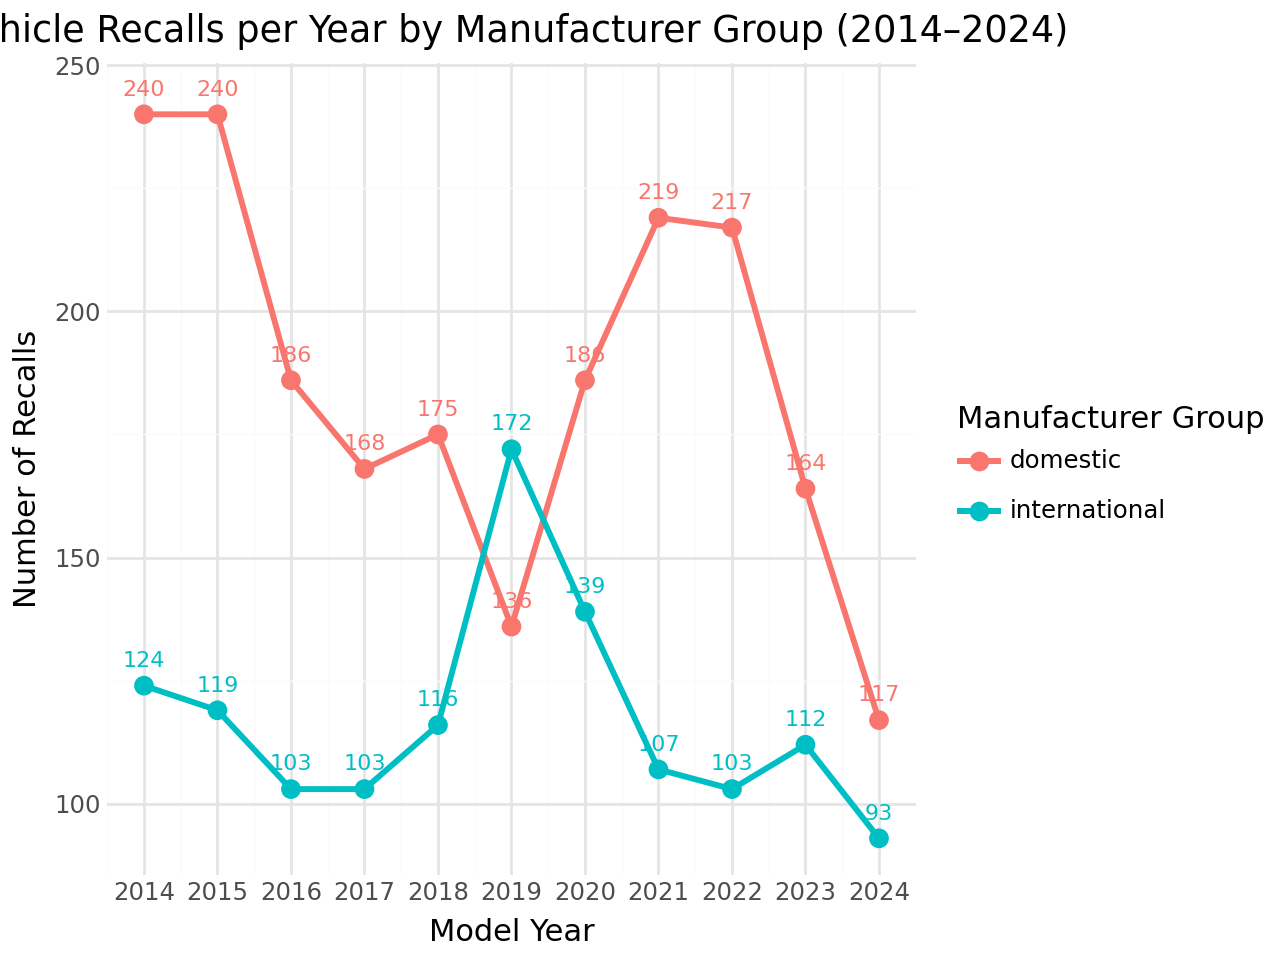

In [ ]:
!pip install plotnine

from plotnine import *

(
     ggplot(trend, aes(x="year", y="recall_count", color="manufacturer_group"))
    + geom_line(size=1.2)
    + geom_point(size=3)
    + geom_text(
        aes(label="recall_count"),
        va="bottom",
        size=8,  
        nudge_y=3  
    )
    + labs(
        title="Vehicle Recalls per Year by Manufacturer Group (2014–2024)",
        x="Model Year",
        y="Number of Recalls",
        color="Manufacturer Group"
    )
    + scale_x_continuous(breaks=sorted(trend["year"].unique()))
    + theme_minimal()
)

## Final Anaylsis and Conclusion

Based on recall data from 2014-2024, domestic manufacturers (Ford, Chevrolet, and Chrysler) consistently had more total recall incidents than international manufacturers (Toyota, Honda, and Hyundai). Domestic recalls stayed above 150 in most years and peaked at 240 in both 2014 and 2015, while international recalls peaked at 172 in 2019, but remained mostly near or below 120 every other year. Both groups showed fluctuations year to year, but the gap between them remained large. 

In conclusion, domesstic manufacturers were more recall-prone overall durring this time range, though the reason why is beyond the scope of this project. However, both groups show an downward trend in recent years, indicating industry-wide changes have been made to help prevent more recalls overall.